# Titanic Dataset
This code was made with the help of ChatGPT

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Import Data

In [2]:
df_titantic = pd.read_csv('data/Titanic-Dataset.csv', header = 0)
df_titantic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print('Shape:', df_titantic.shape)
display(df_titantic.sample(5))
df_titantic.info()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
141,142,1,3,"Nysten, Miss. Anna Sofia",female,22.0,0,0,347081,7.7500,NaN,S
555,556,0,1,"Wright, Mr. George",male,62.0,0,0,113807,26.5500,NaN,S
389,390,1,2,"Lehmann, Miss. Bertha",female,17.0,0,0,SC 1748,12.0000,NaN,C
797,798,1,3,"Osman, Mrs. Mara",female,31.0,0,0,349244,8.6833,NaN,S
454,455,0,3,"Peduzzi, Mr. Joseph",male,NaN,0,0,A/5 2817,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 3. Exploratory EDA

In [4]:
missing = df_titantic.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_titantic) * 100).round(1)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_table[missing_table['missing_count'] > 0]

,missing_count,missing_pct
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


In [5]:
df_titantic.dropna(inplace=True)
df_titantic.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 183 entries, 1 to 889
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  183 non-null    int64  
 1   Survived     183 non-null    int64  
 2   Pclass       183 non-null    int64  
 3   Name         183 non-null    object 
 4   Sex          183 non-null    object 
 5   Age          183 non-null    float64
 6   SibSp        183 non-null    int64  
 7   Parch        183 non-null    int64  
 8   Ticket       183 non-null    object 
 9   Fare         183 non-null    float64
 10  Cabin        183 non-null    object 
 11  Embarked     183 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 18.6+ KB


In [6]:
df_titantic['Embarked'].value_counts()

S    116
C     65
Q      2
Name: Embarked, dtype: int64

In [7]:
df_titantic['Embarked'] = df_titantic['Embarked'].map({'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'})

In [8]:
df_titantic.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,183.0,NaN,NaN,NaN,455.36612,247.052476,2.0,263.5,457.0,676.0,890.0
Survived,183.0,NaN,NaN,NaN,0.672131,0.470725,0.0,0.0,1.0,1.0,1.0
Pclass,183.0,NaN,NaN,NaN,1.191257,0.515187,1.0,1.0,1.0,1.0,3.0
Name,183,183,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,183,2,male,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,183.0,NaN,NaN,NaN,35.674426,15.643866,0.92,24.0,36.0,47.5,80.0
SibSp,183.0,NaN,NaN,NaN,0.464481,0.644159,0.0,0.0,0.0,1.0,3.0
Parch,183.0,NaN,NaN,NaN,0.47541,0.754617,0.0,0.0,0.0,1.0,4.0
Ticket,183,127,113760,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,183.0,NaN,NaN,NaN,78.682469,76.347843,0.0,29.7,57.0,90.0,512.3292


In [9]:
survival_rate = df_titantic['Survived'].mean()
print(f"Overall survival rate: {survival_rate:.2%}")

Overall survival rate: 67.21%


In [10]:
print(pd.crosstab(df_titantic['Sex'], df_titantic['Survived'], normalize='index').round(3))
' ---'
print(pd.crosstab(df_titantic['Pclass'], df_titantic['Survived'], normalize='index').round(3))
'---'
print(pd.crosstab([df_titantic['Sex'], df_titantic['Pclass']], df_titantic['Survived'], normalize='index').round(3))

Survived      0      1
Sex                   
female    0.068  0.932
male      0.568  0.432
Survived      0      1
Pclass                
1         0.329  0.671
2         0.200  0.800
3         0.500  0.500
Survived           0      1
Sex    Pclass              
female 1       0.041  0.959
       2       0.111  0.889
       3       0.400  0.600
male   1       0.583  0.417
       2       0.333  0.667
       3       0.600  0.400


## 4. Good Visuals

Text(0.5, 1.0, 'Titanic: Survival Counts')

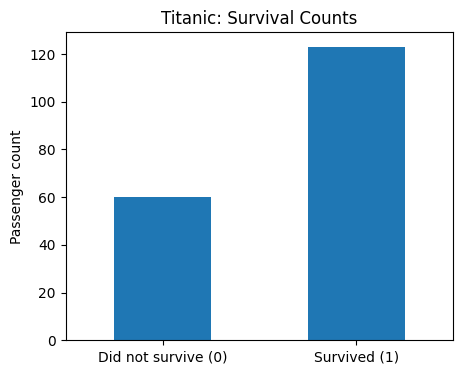

In [11]:
plt.figure(figsize=(5,4))
df_titantic['Survived'].value_counts().sort_index().plot(kind='bar')
plt.xticks([0,1], ['Did not survive (0)', 'Survived (1)'], rotation=0)
plt.ylabel('Passenger count')
plt.title('Titanic: Survival Counts')

(0.0, 1.0)

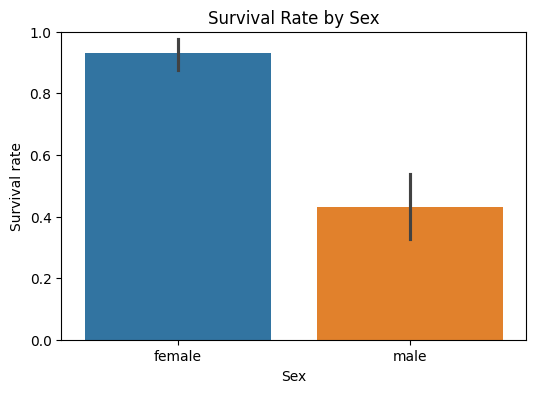

In [12]:
plt.figure(figsize=(6,4))
sns.barplot(data=df_titantic, x='Sex', y='Survived',hue='Sex')
plt.ylabel('Survival rate')
plt.title('Survival Rate by Sex')
plt.ylim(0, 1)

Text(0, 0.5, 'Passenger count')

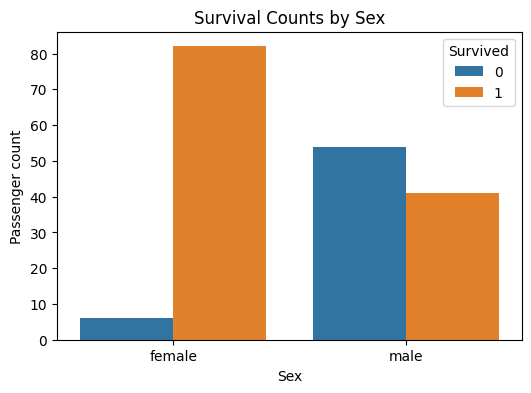

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_titantic, x='Sex', hue='Survived')
plt.title('Survival Counts by Sex')
plt.ylabel('Passenger count')

(0.0, 1.0)

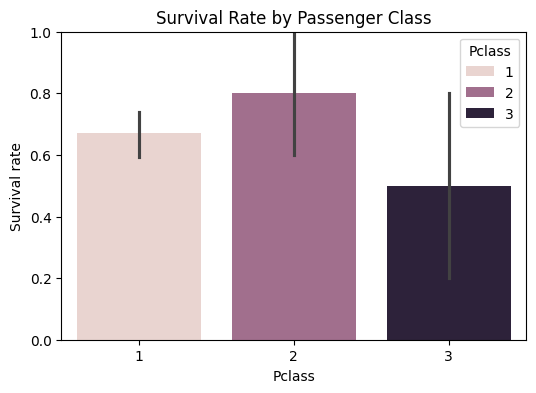

In [14]:
plt.figure(figsize=(6,4))
sns.barplot(data=df_titantic, x='Pclass', y='Survived',hue='Pclass')
plt.ylabel('Survival rate')
plt.title('Survival Rate by Passenger Class')
plt.ylim(0, 1)

In [15]:
df_titantic['Survived'].value_counts()

1    123
0     60
Name: Survived, dtype: int64

Text(0.5, 1.0, 'Age Distribution of Survived vs Not-Survived')

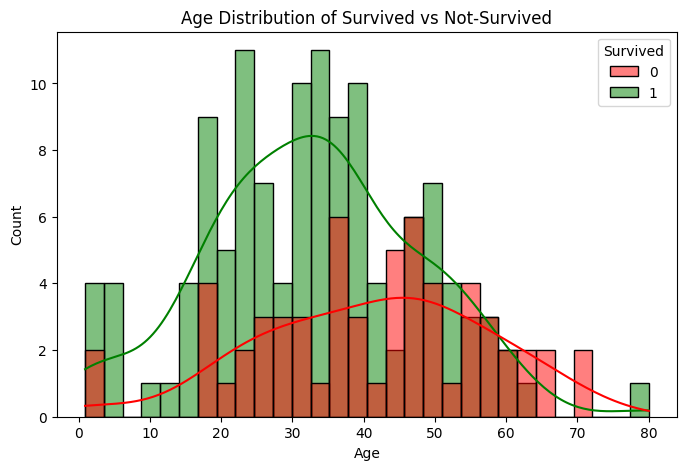

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_titantic, x='Age', hue='Survived', bins = 30, kde = True, palette={0:'red',1: 'green'}, alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution of Survived vs Not-Survived')

In [22]:
df_titantic['Survival_Status'] = df_titantic['Survived'].map({
    0: 'Not Survived',
    1: 'Survived'
})

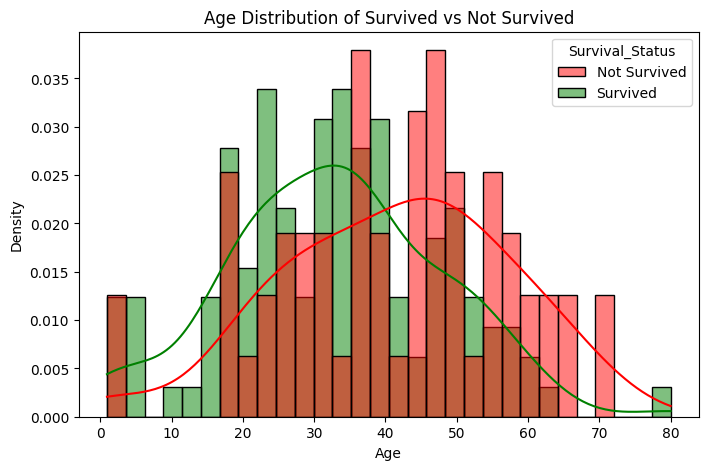

In [36]:
plt.figure(figsize=(8,5))
ax = sns.histplot(
    data=df_titantic,
    x='Age',
    hue='Survival_Status',
    hue_order=['Not Survived', 'Survived'],
    bins=30,
    kde=True,
    palette={'Not Survived': 'red', 'Survived': 'green'},
    stat='density',
    common_norm=False
)

plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Age Distribution of Survived vs Not Survived')
plt.show()

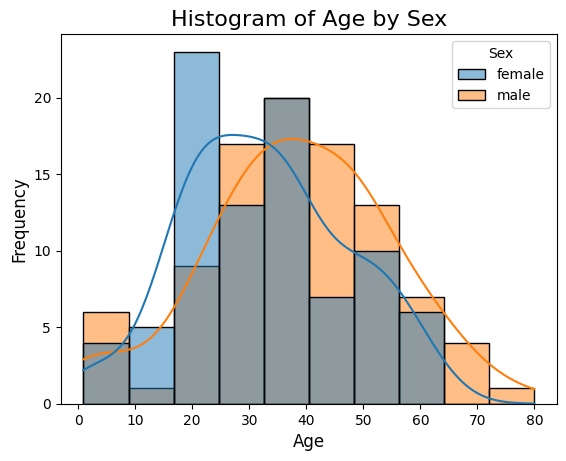

In [24]:
sns.histplot(data=df_titantic, x='Age', hue='Sex', kde=True)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Age by Sex', fontsize=16)
plt.show()

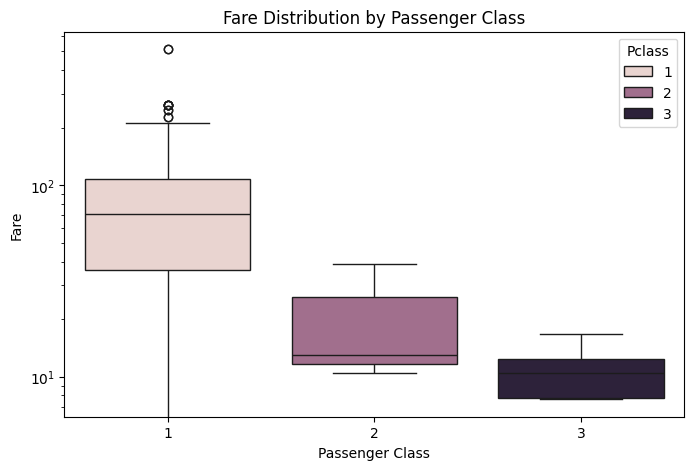

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Pclass', y='Fare', data=df_titantic, hue='Pclass')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.title('Fare Distribution by Passenger Class')
plt.yscale('log')

## 5. Misleading Visuals

(0.4, 0.8)

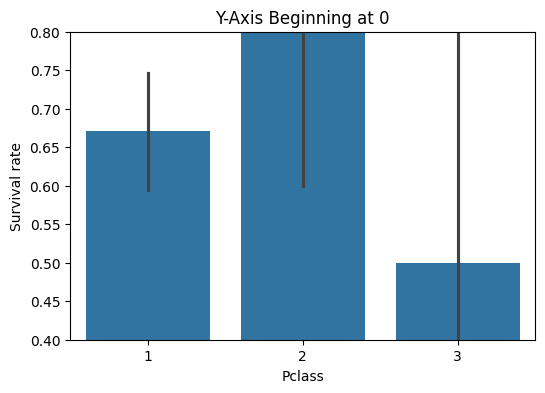

In [26]:
plt.figure(figsize=(6,4))
sns.barplot(data=df_titantic, x='Pclass', y='Survived')
plt.title('Y-Axis Beginning at 0')
plt.ylabel('Survival rate')
plt.ylim(0.4, 0.8)

In [27]:
df_age = df_titantic.dropna(subset=['Age'])

In [28]:
ages = df_age['Age'].head(15)

([<matplotlib.patches.Wedge at 0x27b5e46e210>,
 [Text(1.0743753438054007, 0.23604580196018604, '38.0'),
  Text(0.8877056466081714, 0.6495988646695502, '35.0'),
  Text(0.4610941863485061, 0.9986952244381714, '54.0'),
  Text(0.11249058193193541, 1.0942330048836102, '4.0'),
  Text(-0.27258853838262237, 1.0656901466854358, '58.0'),
  Text(-0.7689136662251448, 0.7866204764002821, '34.0'),
  Text(-0.993382189210282, 0.4724318217052993, '28.0'),
  Text(-1.0829242012874645, 0.19306779707115146, '19.0'),
  Text(-1.0757013497832812, -0.22992739304925558, '49.0'),
  Text(-0.7181938284049667, -0.8331852284102361, '65.0'),
  Text(-0.09379229613825266, -1.0959940716925045, '45.0'),
  Text(0.3624626799165606, -1.038566707374979, '29.0'),
  Text(0.6596609448820286, -0.880254189309741, '25.0'),
  Text(0.8726886690956921, -0.6696375787185108, '23.0'),
  Text(1.0625184100286265, -0.2847009454677663, '46.0')],
 [Text(0.5860229148029458, 0.12875225561464693, '6.9%'),
  Text(0.4842030799680934, 0.3543266534

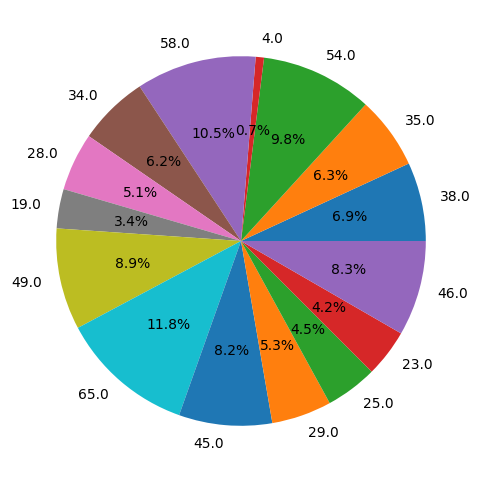

In [29]:
plt.figure(figsize=(6,6))
plt.pie(ages, labels=ages, autopct='%1.1f%%')

In [30]:
df_titantic.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 183 entries, 1 to 889
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      183 non-null    int64  
 1   Survived         183 non-null    int64  
 2   Pclass           183 non-null    int64  
 3   Name             183 non-null    object 
 4   Sex              183 non-null    object 
 5   Age              183 non-null    float64
 6   SibSp            183 non-null    int64  
 7   Parch            183 non-null    int64  
 8   Ticket           183 non-null    object 
 9   Fare             183 non-null    float64
 10  Cabin            183 non-null    object 
 11  Embarked         183 non-null    object 
 12  Survival_Status  183 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 20.0+ KB


In [31]:
df_titantic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survival_Status
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,Cherbourg,Survived
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,Southampton,Survived
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,Southampton,Not Survived
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,Southampton,Survived
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,Southampton,Survived


In [32]:
df_titantic['PassengerId']

1        2
3        4
6        7
10      11
11      12
      ... 
871    872
872    873
879    880
887    888
889    890
Name: PassengerId, Length: 183, dtype: int64

In [33]:
ids = df_titantic['PassengerId'].head(30)

Text(0.5, 1.0, 'Awful Pie Chart of Passenger Ids')

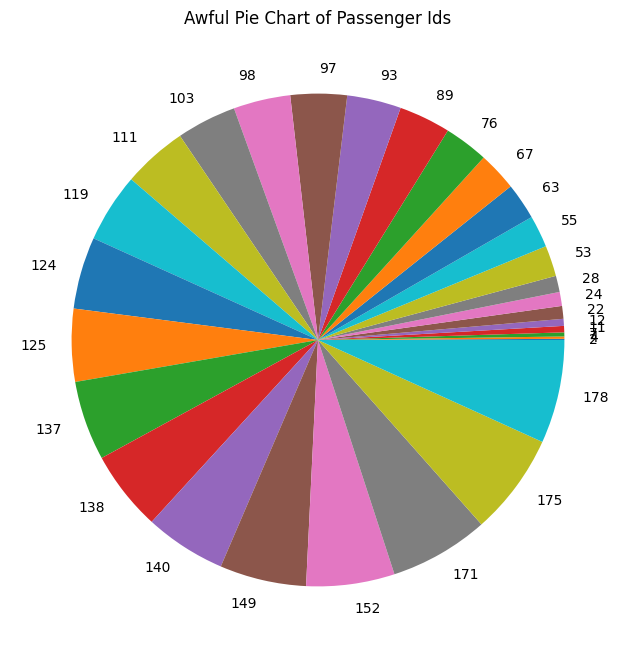

In [34]:
plt.figure(figsize=(8,8))
plt.pie(ids, labels=ids)
plt.title('Awful Pie Chart of Passenger Ids')